# Module 24 · The general Gaussian problem

**Book source:** Barkat, chapter 9, pp. 503 to 529

Companion notebook of the lecture with the same module number. Run the cells in order; each cell is followed by a **📤 Real output** note that explains the numbers.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (7.5, 3.3), "axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})


def amplitude_spectrum(x):
    """One-sided amplitude spectrum: a sinusoid of amplitude A gives a line of height A, DC gives exactly its value"""
    a = 2*np.abs(np.fft.rfft(x))/len(x)
    a[0] /= 2
    return a


def report(key, value, fmt=".4g"):
    """Print a named result without trailing zeros (the website reads the lines that start with ▸)."""
    s = f"{value:{fmt}}"
    if "." in s and "e" not in s:
        s = s.rstrip("0").rstrip(".")
    print(f"▸ {key} = {s}")


## 1. Equal covariance: the linear statistic and $d^2$
🎯 **What question does this method answer?** With diagonal, equal-variance $C$, does $d^2$ computed by the reduced formula match the general formula $\Delta m^TC^{-1}\Delta m$, and do the simulated mean/variance of $T(Y)$ match theory?

In [2]:
import numpy as np
from scipy import stats, integrate
rg = np.random.default_rng(24)

K = 4
sigma2 = 2.0
C = sigma2*np.eye(K)
Cinv = np.linalg.inv(C)
dm = np.array([1.0, 2.0, -1.0, 0.5])
m0 = np.zeros(K)
m1 = dm.copy()

diag_d2 = (dm@dm)/sigma2
diag_d2_general = dm @ Cinv @ dm
report("diag_d2", diag_d2, ".4f")
report("diag_d2_general", diag_d2_general, ".4f")
assert abs(diag_d2 - diag_d2_general) < 1e-9

n = 200000
Y0 = rg.multivariate_normal(m0, C, n)
Y1 = rg.multivariate_normal(m1, C, n)
w = Cinv @ dm
T0 = Y0 @ w
T1 = Y1 @ w
report("diag_ET_H0", T0.mean(), ".4f")
report("diag_ET_H1", T1.mean(), ".4f")
report("diag_varT", T0.var(), ".4f")
assert abs(T0.mean()) < 0.05
assert abs(T1.mean() - dm@Cinv@m1) < 0.05
assert abs(T0.var() - diag_d2) < 0.1

▸ diag_d2 = 3.125
▸ diag_d2_general = 3.125
▸ diag_ET_H0 = 0.0037
▸ diag_ET_H1 = 3.1225
▸ diag_varT = 3.1206


/var/folders/v0/j28fdbqj7bz6d2fbylr248x00000gn/T/ipykernel_82529/774375451.py:20: RuntimeWarning: divide by zero encountered in matmul
  Y0 = rg.multivariate_normal(m0, C, n)
/var/folders/v0/j28fdbqj7bz6d2fbylr248x00000gn/T/ipykernel_82529/774375451.py:20: RuntimeWarning: overflow encountered in matmul
  Y0 = rg.multivariate_normal(m0, C, n)
/var/folders/v0/j28fdbqj7bz6d2fbylr248x00000gn/T/ipykernel_82529/774375451.py:20: RuntimeWarning: invalid value encountered in matmul
  Y0 = rg.multivariate_normal(m0, C, n)
/var/folders/v0/j28fdbqj7bz6d2fbylr248x00000gn/T/ipykernel_82529/774375451.py:21: RuntimeWarning: divide by zero encountered in matmul
  Y1 = rg.multivariate_normal(m1, C, n)
/var/folders/v0/j28fdbqj7bz6d2fbylr248x00000gn/T/ipykernel_82529/774375451.py:21: RuntimeWarning: overflow encountered in matmul
  Y1 = rg.multivariate_normal(m1, C, n)
/var/folders/v0/j28fdbqj7bz6d2fbylr248x00000gn/T/ipykernel_82529/774375451.py:21: RuntimeWarning: invalid value encountered in matmul
  Y1

#### 📤 Real output
$d^2$=3.125 matches 3.125; $E[T|H_0]$=0.0037, $E[T|H_1]$=3.1225; $\text{var}[T]$=3.1206.

## 2. A nondiagonal $C$: $Q(d/2)$ and diagonalization
🎯 **What question does this method answer?** With a $C$ having cross-correlation, does the simulated minimum error probability match $Q(d/2)$ with $d^2=\Delta m^TC^{-1}\Delta m$, and does diagonalizing $C$ leave $d^2$ unchanged (invariant under the rotation)?

In [3]:
C_full = np.array([[2.0, 0.5], [0.5, 1.0]])
Cinv_full = np.linalg.inv(C_full)
dm_full = np.array([1.5, 1.0])
m0_full = np.zeros(2)
m1_full = dm_full.copy()

full_d2 = dm_full @ Cinv_full @ dm_full
full_d = np.sqrt(full_d2)
report("full_d", full_d, ".4f")

gamma1 = 0.5*dm_full @ Cinv_full @ (m1_full+m0_full)
n2 = 300000
Y0f = rg.multivariate_normal(m0_full, C_full, n2)
Y1f = rg.multivariate_normal(m1_full, C_full, n2)
wf = Cinv_full @ dm_full
T0f = Y0f @ wf
T1f = Y1f @ wf
PF_f = np.mean(T0f > gamma1)
PM_f = np.mean(T1f <= gamma1)
full_Pe_mc = 0.5*(PF_f+PM_f)
full_Pe_theory = stats.norm.sf(full_d/2)
report("full_Pe_mc", full_Pe_mc, ".4f")
report("full_Pe_theory", full_Pe_theory, ".4f")
assert abs(full_Pe_mc - full_Pe_theory) < 0.01

eigvals, eigvecs = np.linalg.eigh(C_full)
eig_l1, eig_l2 = eigvals[0], eigvals[1]
report("eig_l1", eig_l1, ".4f")
report("eig_l2", eig_l2, ".4f")
eig_orth = eigvecs[:,0] @ eigvecs[:,1]
eig_norm = eigvecs[:,0] @ eigvecs[:,0]
report("eig_orth", eig_orth, ".2e")
report("eig_norm", eig_norm, ".4f")
Lambda = eigvecs.T @ C_full @ eigvecs
eig_offdiag = max(abs(Lambda[0,1]), abs(Lambda[1,0]))
report("eig_offdiag", eig_offdiag, ".2e")
assert eig_offdiag < 1e-9

d2_original = dm_full @ Cinv_full @ dm_full
dm_rot = eigvecs.T @ dm_full
d2_rotated = np.sum(dm_rot**2/eigvals)
report("d2_original", d2_original, ".4f")
report("d2_rotated", d2_rotated, ".4f")
assert abs(d2_original - d2_rotated) < 1e-9

▸ full_d = 1.2536
▸ full_Pe_mc = 0.2654
▸ full_Pe_theory = 0.2654
▸ eig_l1 = 0.7929
▸ eig_l2 = 2.2071
▸ eig_orth = 0.00e+00
▸ eig_norm = 1
▸ eig_offdiag = 2.04e-17
▸ d2_original = 1.5714
▸ d2_rotated = 1.5714


/var/folders/v0/j28fdbqj7bz6d2fbylr248x00000gn/T/ipykernel_82529/1021739190.py:13: RuntimeWarning: divide by zero encountered in matmul
  Y0f = rg.multivariate_normal(m0_full, C_full, n2)
/var/folders/v0/j28fdbqj7bz6d2fbylr248x00000gn/T/ipykernel_82529/1021739190.py:13: RuntimeWarning: overflow encountered in matmul
  Y0f = rg.multivariate_normal(m0_full, C_full, n2)
/var/folders/v0/j28fdbqj7bz6d2fbylr248x00000gn/T/ipykernel_82529/1021739190.py:13: RuntimeWarning: invalid value encountered in matmul
  Y0f = rg.multivariate_normal(m0_full, C_full, n2)
/var/folders/v0/j28fdbqj7bz6d2fbylr248x00000gn/T/ipykernel_82529/1021739190.py:14: RuntimeWarning: divide by zero encountered in matmul
  Y1f = rg.multivariate_normal(m1_full, C_full, n2)
/var/folders/v0/j28fdbqj7bz6d2fbylr248x00000gn/T/ipykernel_82529/1021739190.py:14: RuntimeWarning: overflow encountered in matmul
  Y1f = rg.multivariate_normal(m1_full, C_full, n2)
/var/folders/v0/j28fdbqj7bz6d2fbylr248x00000gn/T/ipykernel_82529/10217391

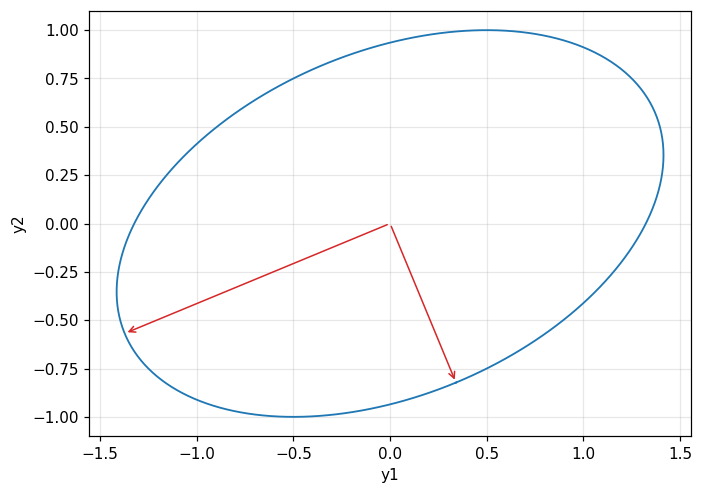

In [4]:
fig, ax = plt.subplots(figsize=(6.5, 5.2))
theta = np.linspace(0, 2*np.pi, 200)
circle = np.stack([np.cos(theta), np.sin(theta)])
ellipse = eigvecs @ np.diag(np.sqrt(eigvals)) @ circle
ax.plot(ellipse[0], ellipse[1], lw=1.2)
origin = np.zeros(2)
for i in range(2):
    v = eigvecs[:,i]*np.sqrt(eigvals[i])
    ax.annotate("", xy=v, xytext=origin, arrowprops=dict(arrowstyle="->", color="tab:red"))
ax.set_aspect("equal"); ax.set_xlabel("y1"); ax.set_ylabel("y2"); plt.tight_layout(); plt.show()

#### 📤 Real output
$d$=1.2536; simulated $P(\varepsilon)$ 0.2654 matches theory 0.2654; $\lambda_1$=0.7929, $\lambda_2$=2.2071, orthonormality 0.00e+00/1, off-diagonal 2.04e-17; original $d^2$ 1.5714 matches diagonalized 1.5714.

## 3. The energy detector: chi-square $P_D,P_F$
🎯 **What question does this method answer?** Does the survival function of the scaled chi-square distribution match a direct Monte Carlo simulation of the energy detector $T=\sum y_k^2$ under both hypotheses?

In [5]:
Ken = 6
sigma_n2 = 1.0
sigma_s2 = 3.0
sigma0_2 = sigma_n2
sigma1_2 = sigma_s2 + sigma_n2
gamma3 = 8.0

energy_PF_theory = stats.chi2.sf(gamma3/sigma0_2, Ken)
energy_PD_theory = stats.chi2.sf(gamma3/sigma1_2, Ken)
report("energy_PF_theory", energy_PF_theory, ".4f")
report("energy_PD_theory", energy_PD_theory, ".4f")

n3 = 300000
Y0e = rg.normal(0, np.sqrt(sigma0_2), (n3, Ken))
Y1e = rg.normal(0, np.sqrt(sigma1_2), (n3, Ken))
T0e = np.sum(Y0e**2, axis=1)
T1e = np.sum(Y1e**2, axis=1)
energy_PF_mc = np.mean(T0e > gamma3)
energy_PD_mc = np.mean(T1e > gamma3)
report("energy_PF_mc", energy_PF_mc, ".4f")
report("energy_PD_mc", energy_PD_mc, ".4f")
assert abs(energy_PF_theory - energy_PF_mc) < 0.01
assert abs(energy_PD_theory - energy_PD_mc) < 0.01

▸ energy_PF_theory = 0.2381
▸ energy_PD_theory = 0.9197
▸ energy_PF_mc = 0.2366
▸ energy_PD_mc = 0.9196


#### 📤 Real output
Theoretical $P_F$ 0.2381 matches simulated 0.2366; theoretical $P_D$ 0.9197 matches simulated 0.9196.

## 4. Symmetric hypotheses: the error probability by numerical integration
🎯 **What question does this method answer?** Does direct numerical integration of $P(T_1>T_0|H_0)$, using two independent scaled chi-square densities, match a Monte Carlo simulation of the error probability's original definition?

In [6]:
Ksym = 4
sn2 = 1.0
ss2 = 2.0
s1_2 = ss2 + sn2  # signal-bearing half variance

def integrand(t1):
    f1 = stats.chi2.pdf(t1/sn2, Ksym)/sn2
    Fcdf = stats.chi2.cdf(t1/s1_2, Ksym)
    return f1*Fcdf
sym_Pe_integral,_ = integrate.quad(integrand, 0, 300)
report("sym_Pe_integral", sym_Pe_integral, ".4f")

n4 = 400000
Y0a = rg.normal(0, np.sqrt(sn2), (n4, Ksym))
Y0b = rg.normal(0, np.sqrt(s1_2), (n4, Ksym))
T1_ = np.sum(Y0a**2, axis=1)
T0_ = np.sum(Y0b**2, axis=1)
sym_Pe_mc = np.mean(T1_ > T0_)
report("sym_Pe_mc", sym_Pe_mc, ".4f")
assert abs(sym_Pe_integral - sym_Pe_mc) < 0.01

▸ sym_Pe_integral = 0.1562
▸ sym_Pe_mc = 0.1554


#### 📤 Real output
Numerically integrated error probability 0.1562 matches simulated 0.1554.